In [1]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://sudden-cons-wallace-volume.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [6]:
# ─────────────────────────────────────────────
# 분석 환경 세팅 — 패키지 / 한글 폰트 / 출력 옵션
# ─────────────────────────────────────────────

# [1] 패키지 설치 + 그래프 인라인 출력
!apt-get -y install fonts-nanum -q
%matplotlib inline

# [2] 임포트
import os
import platform
import warnings
import matplotlib.font_manager as fm # 폰트 처리
import plotly.io as pio # 그래프의 렌더링 설정, 파일 출력

# 라이브러리는 각 학습에 맞게 수정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# [3] 경고 숨기기 + 난수 고정(결과 재현용)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(42)

# [4] 한글 폰트 확보
#     리눅스(코랩)는 폰트 캐시가 갱신 안 되는 경우가 많아,
#     나눔고딕을 목록 맨 앞에 직접 끼워넣어 우선 적용시킴
if platform.system() == "Linux":
    nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    font_family = "DejaVu Sans"
    if os.path.exists(nanum_path):
        fm.fontManager.addfont(nanum_path)
        font_family = fm.FontProperties(fname=nanum_path).get_name()  # "NanumGothic"
else:
    # 맥 / 윈도우 로컬 환경
    font_family = "AppleGothic" if platform.system() == "Darwin" else "Malgun Gothic"

# [5] 스타일 → 개별 설정 순서로 적용 (seaborn이 rcParams를 덮어쓰기 때문)
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# [6] 코랩 전용 출력 옵션 (없는 환경이면 조용히 통과)
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    pio.renderers.default = "colab"
except ImportError:
    pass

print(f"준비 완료! [적용 폰트: {font_family}]")

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
준비 완료! [적용 폰트: NanumGothic]


In [7]:
# ─────────────────────────────────────────────
# [C1] ◀ ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

# 지난 순서와 동일한 수치형 10개 열 — 비교의 조건을 고정합니다
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {shoppers['Revenue'].mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


In [8]:
# [C2] ◀ 문제 1. 단일 트리를 얹어 본다
# ⌨️ 문제 1 — 베이스라인 · 로지스틱 · 단일 트리를 나란히
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1) X, y 준비 및 8:2 분리
X = shoppers[NUM_COLS].values
y = shoppers["Revenue"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 로지스틱 회귀는 스케일링 필요 (트리/더미는 필요 없지만, 동일 분리셋 사용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2) 세 모델 학습
results = []

# ① DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
train_acc = dummy.score(X_train, y_train)
test_acc = dummy.score(X_test, y_test)
results.append(["DummyClassifier", train_acc, test_acc, train_acc - test_acc])

# ② LogisticRegression (스케일링된 데이터 사용)
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
train_acc = logreg.score(X_train_scaled, y_train)
test_acc = logreg.score(X_test_scaled, y_test)
results.append(["LogisticRegression", train_acc, test_acc, train_acc - test_acc])

# ③ DecisionTreeClassifier (기본 설정, 깊이 제한 없음 → 스케일링 불필요)
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
train_acc = tree.score(X_train, y_train)
test_acc = tree.score(X_test, y_test)
results.append(["DecisionTreeClassifier", train_acc, test_acc, train_acc - test_acc])

# 결과 표 출력
result_df = pd.DataFrame(results, columns=["모델", "학습 정확도", "테스트 정확도", "격차(학습-테스트)"])
result_df[["학습 정확도", "테스트 정확도", "격차(학습-테스트)"]] = result_df[
    ["학습 정확도", "테스트 정확도", "격차(학습-테스트)"]
].round(4)

print(result_df.to_string(index=False))

                    모델  학습 정확도  테스트 정확도  격차(학습-테스트)
       DummyClassifier  0.8453   0.8451      0.0002
    LogisticRegression  0.8839   0.8796      0.0044
DecisionTreeClassifier  0.9998   0.8423      0.1575


**베이스라인 (0.8451)**
구매 전환율이 약 15%라는 뜻은, "항상 안 산다"고만 찍어도 84.5%는 맞는다는 겁니다. 즉 이 숫자 밑으로 떨어지는 모델은 의미가 없습니다.

**로지스틱 회귀 (0.8796)**
베이스라인보다 3.4%p 개선. 학습-테스트 격차도 0.0044로 거의 없음 — 안정적이고 일반화가 잘 되는 모델입니다.

**단일 트리 (0.8423)**
여기서 진짜 문제가 보입니다:
- 학습 정확도 **0.9998** → 거의 완벽하게 외웠다는 뜻 (극단적 과적합)
- 테스트 정확도 **0.8423** → 심지어 **베이스라인보다도 낮습니다**
- 격차 **0.1575** → 로지스틱 회귀 격차(0.0044)의 약 36배

**무슨 일이 일어난 걸까요?**
깊이 제한 없는 트리는 훈련 데이터의 리프 노드가 순수해질 때까지(불순도 0) 계속 분기합니다. 그 결과 훈련셋의 노이즈, 이상치, 우연한 패턴까지 전부 "규칙"으로 외워버립니다. 학습 정확도 99.98%는 실력이 아니라 **암기**입니다. 새로운 데이터(테스트셋)에는 그 암기한 규칙들이 안 맞아서, 오히려 아무것도 모르는 베이스라인보다 성능이 떨어지는 역설적인 상황이 벌어졌습니다.

max_depth  학습 정확도  테스트 정확도  격차(학습-테스트)
        2  0.8922   0.8861      0.0062
        3  0.8932   0.8832      0.0100
        5  0.9049   0.8942      0.0107
        8  0.9253   0.8881      0.0372
       12  0.9572   0.8747      0.0825
     None  0.9998   0.8423      0.1575

최고 테스트 정확도 깊이: max_depth=5 (테스트 정확도=0.8942, 격차=0.0107)


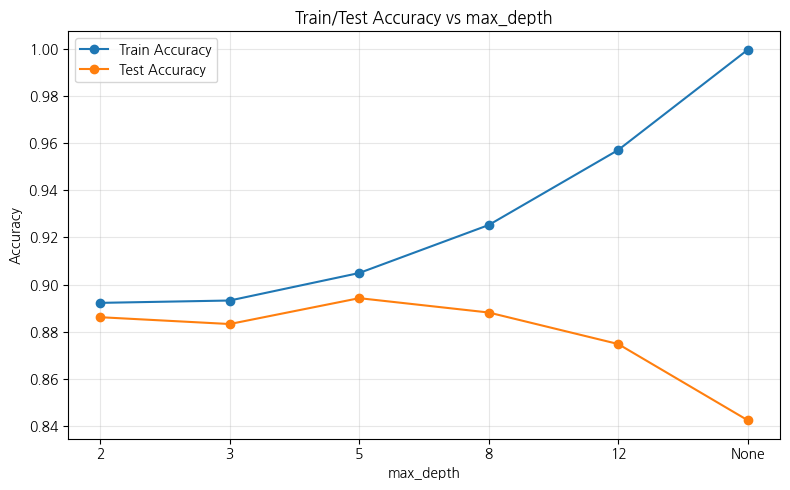

In [10]:
# [C3] ◀ 문제 2. 가지치기로 격차를 줄인다
# ⌨️ 문제 2 — max_depth를 훑어 과적합을 통제하기

depths = [2, 3, 5, 8, 12, None]
rows = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    rows.append({
        "max_depth": str(depth),
        "학습 정확도": round(train_acc, 4),
        "테스트 정확도": round(test_acc, 4),
        "격차(학습-테스트)": round(train_acc - test_acc, 4)
    })

depth_df = pd.DataFrame(rows)
print(depth_df.to_string(index=False))

# 2) 테스트 정확도가 가장 높은 깊이 찾기
best_row = depth_df.loc[depth_df["테스트 정확도"].idxmax()]
print(f"\n최고 테스트 정확도 깊이: max_depth={best_row['max_depth']} "
      f"(테스트 정확도={best_row['테스트 정확도']}, 격차={best_row['격차(학습-테스트)']})")

# 3) 선 그래프 — 라벨은 영어로 (한글 폰트 미설치 환경 대응)
x_pos = range(len(depths))

plt.figure(figsize=(8, 5))
plt.plot(x_pos, depth_df["학습 정확도"], marker='o', label='Train Accuracy')
plt.plot(x_pos, depth_df["테스트 정확도"], marker='o', label='Test Accuracy')
plt.xticks(x_pos, depth_df["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train/Test Accuracy vs max_depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**전체 패턴 읽기**

두 곡선의 관계가 세 구간으로 나뉩니다:

1. **depth 2~5: 같이 상승 (좋은 구간)**
학습 정확도와 테스트 정확도가 함께 올라갑니다. 트리가 깊어지면서 실제로 유용한 패턴(예: `PageValues`가 높으면 구매 확률이 높다 같은 진짜 규칙)을 더 잘 잡아내고 있다는 뜻입니다. 격차도 0.006~0.011로 여전히 작습니다.

2. **depth 5 = 변곡점**
테스트 정확도가 **0.8942로 최고점**을 찍고 여기서부터 방향을 바꿉니다. 이 지점이 "일반화 가능한 패턴은 다 뽑아냈다"는 신호입니다.

3. **depth 8 → 12 → None: 갈라짐 (나쁜 구간)**
학습 정확도는 계속 올라가 결국 0.9998까지 가지만, 테스트 정확도는 오히려 **떨어집니다** (0.8942 → 0.8881 → 0.8747 → 0.8423). 격차가 0.011 → 0.037 → 0.083 → 0.158로 기하급수적으로 벌어집니다. depth 5 이후에 추가되는 분기들은 진짜 패턴이 아니라 훈련 데이터의 노이즈를 외우는 데 쓰이고 있다는 뜻입니다.

**결론**

- **최적 지점: `max_depth=5`** — 테스트 정확도 최고(0.8942)이면서 격차도 여전히 건전한 수준(0.0107)
- 문제 1의 로지스틱 회귀(0.8796)를 이제 **넘어섰습니다** — 적절히 제한된 트리가 선형 모델보다 낫다는 것을 확인
- `max_depth=8`부터는 테스트 성능이 이미 손해를 보기 시작하므로, "더 복잡하게 = 더 낫게"라는 직관이 트리에서는 틀렸다는 것을 데이터로 직접 확인한 셈입니다


In [11]:
# [C4] ◀ 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다
# ⌨️ 문제 3 — 랜덤포레스트·XGBoost를 더해 비교표 완성
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def add(name, model, X_tr, y_tr, X_te, y_te):
    """모델을 학습시키고 학습·테스트·격차를 dict로 반환"""
    model.fit(X_tr, y_tr)
    train_acc = model.score(X_tr, y_tr)
    test_acc = model.score(X_te, y_te)
    return {
        "모델": name,
        "학습 정확도": round(train_acc, 4),
        "테스트 정확도": round(test_acc, 4),
        "격차(학습-테스트)": round(train_acc - test_acc, 4)
    }

# 지금까지의 결과를 같은 형식(dict)으로 다시 모음
final_rows = [
    {"모델": "① DummyClassifier", "학습 정확도": 0.8453, "테스트 정확도": 0.8451, "격차(학습-테스트)": 0.0002},
    {"모델": "② LogisticRegression", "학습 정확도": 0.8839, "테스트 정확도": 0.8796, "격차(학습-테스트)": 0.0044},
    {"모델": "③ DecisionTree(제한없음)", "학습 정확도": 0.9998, "테스트 정확도": 0.8423, "격차(학습-테스트)": 0.1575},
]

# ③′ 가지치기한 트리 (max_depth=5) — 원래 데이터로 재학습
tree_pruned = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
final_rows.append(add("③′ Tree(max_depth=5)", tree_pruned, X_train, y_train, X_test, y_test))

# ④ RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
final_rows.append(add("④ RandomForest(n=300)", rf, X_train, y_train, X_test, y_test))

# ⑤ XGBClassifier
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0,
    eval_metric="logloss", random_state=RANDOM_STATE
)
final_rows.append(add("⑤ XGBoost", xgb, X_train, y_train, X_test, y_test))

# 최종 비교표 — 테스트 정확도 내림차순
final_df = pd.DataFrame(final_rows).sort_values("테스트 정확도", ascending=False).reset_index(drop=True)
print(final_df.to_string(index=False))

                   모델  학습 정확도  테스트 정확도  격차(학습-테스트)
④ RandomForest(n=300)  0.9998   0.8958      0.1040
 ③′ Tree(max_depth=5)  0.9049   0.8942      0.0107
            ⑤ XGBoost  0.9451   0.8873      0.0578
 ② LogisticRegression  0.8839   0.8796      0.0044
    ① DummyClassifier  0.8453   0.8451      0.0002
 ③ DecisionTree(제한없음)  0.9998   0.8423      0.1575


숫자를 자세히 보면 보고의 핵심이 딱 보입니다.

**표 해석**

| 순위 | 모델 | 테스트 정확도 | 격차 |
|---|---|---|---|
| 1 | RandomForest | 0.8958 | 0.1040 |
| 2 | Tree(depth=5) | 0.8942 | 0.0107 |
| 3 | XGBoost | 0.8873 | 0.0578 |
| 4 | LogisticRegression | 0.8796 | 0.0044 |
| 5 | Dummy | 0.8451 | 0.0002 |
| 6 | Tree(제한없음) | 0.8423 | 0.1575 |

**여기서 흥미로운 지점**

1위 랜덤포레스트(0.8958)와 2위 가지치기 트리(0.8942)의 **테스트 정확도 차이는 0.0016**밖에 안 됩니다. 거의 동급이라 봐도 됩니다.

그런데 격차를 보면 랜덤포레스트는 **0.1040** — 이는 depth=5 트리(0.0107)의 거의 **10배**입니다. 랜덤포레스트는 학습 정확도가 0.9998까지 올라가는 걸 봐도, 300개 트리를 앙상블해도 여전히 훈련 데이터에 상당히 밀착돼 있다는 뜻입니다. (다만 배깅 덕분에 단일 트리 제한없음(격차 0.1575)보다는 낫습니다.)

XGBoost(0.8873, 격차 0.0578)는 그 중간 어딘가에 있습니다 — depth=5 트리보다는 덜 안정적이지만 RF보다는 낫습니다.

**팀장께 보고할 문장 (초안)**

> 4개 모델을 비교한 결과, 랜덤포레스트가 테스트 정확도 89.58%로 1위지만, 가지치기한 단일 트리(89.42%)와의 차이는 0.16%p에 불과합니다. 반면 랜덤포레스트의 학습-테스트 격차(10.4%p)는 가지치기 트리(1.07%p)의 약 10배로, 안정성 면에서는 훨씬 불리합니다. 성능 차이가 미미하고 해석과 유지보수가 훨씬 쉬운 단일 트리(depth=5)를 기본 모델로, 랜덤포레스트는 추가 개선이 필요할 때 후보로 검토하는 것을 제안합니다.

이 문장이 말하는 건 "숫자가 1등이라고 무조건 채택"이 아니라 — **미미한 성능 이득 대비 안정성 손실이 너무 크다**는 게 이번 비교표의 진짜 메시지라는 겁니다. 팀장이 물었던 "앙상블이 얼마나 이겼나?"에 대한 정직한 답은 "이겼지만, 그 승리가 비용(과적합 위험)을 정당화할 만큼 크지는 않다"인 셈이죠.

상위 3개 피처 중요도:
PageValues                 0.4133
ProductRelated_Duration    0.1194
ExitRates                  0.1178
dtype: float64


[PageValues 기준]
                  mean  size
PageValues = 0  0.0385  9600
PageValues > 0  0.5634  2730

[ExitRates 기준 (중앙값=0.0252)]
                       mean  size
ExitRates <= 0.0252  0.2352  6165
ExitRates > 0.0252   0.0743  6165

[ProductRelated_Duration 기준 (중앙값=598.9)]
                     mean  size
Duration <= 598.9  0.0866  6165
Duration > 598.9   0.2229  6165


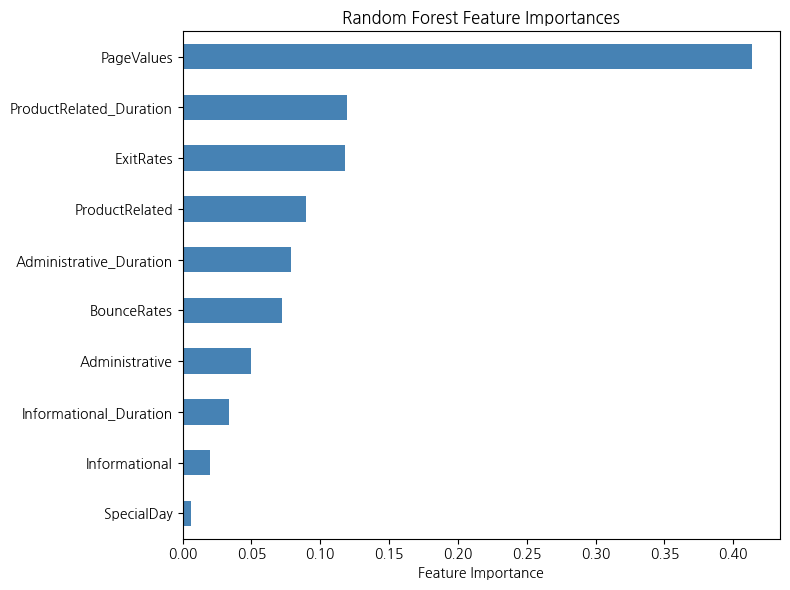

In [12]:
# [C5] ◀ 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다
# ⌨️ 문제 4 — 중요도 막대 + 상위 3개의 구매율 대비

# 1) 랜덤포레스트 피처 중요도 — 가로 막대 (오름차순 정렬해야 1위가 맨 위)
importances = pd.Series(rf.feature_importances_, index=NUM_COLS)
importances_sorted = importances.sort_values()  # 오름차순

plt.figure(figsize=(8, 6))
importances_sorted.plot(kind="barh", color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# 상위 3개 피처 (내림차순 기준)
top3 = importances.sort_values(ascending=False).head(3)
print("상위 3개 피처 중요도:")
print(top3.round(4))
print()

# 2) 상위 3개 피처별로 값이 큰/작은 세션의 구매율 비교
print("=" * 60)

# ① PageValues — 0 vs 0보다 큰 세션
grp = shoppers.groupby(shoppers["PageValues"] > 0)["Revenue"].agg(["mean", "size"])
grp.index = ["PageValues = 0", "PageValues > 0"]
print("\n[PageValues 기준]")
print(grp.round(4))

# ② ExitRates — 중앙값 기준
median_exit = shoppers["ExitRates"].median()
grp = shoppers.groupby(shoppers["ExitRates"] > median_exit)["Revenue"].agg(["mean", "size"])
grp.index = [f"ExitRates <= {median_exit:.4f}", f"ExitRates > {median_exit:.4f}"]
print(f"\n[ExitRates 기준 (중앙값={median_exit:.4f})]")
print(grp.round(4))

# ③ ProductRelated_Duration — 중앙값 기준
median_dur = shoppers["ProductRelated_Duration"].median()
grp = shoppers.groupby(shoppers["ProductRelated_Duration"] > median_dur)["Revenue"].agg(["mean", "size"])
grp.index = [f"Duration <= {median_dur:.1f}", f"Duration > {median_dur:.1f}"]
print(f"\n[ProductRelated_Duration 기준 (중앙값={median_dur:.1f})]")
print(grp.round(4))

하나씩 "마케팅팀이 읽을 수 있는 문장"으로 옮겨보겠습니다.

**① PageValues — 압도적 1위 (중요도 0.4133)**

> PageValues가 0보다 큰 세션(고가치 페이지를 한 번이라도 본 세션)은 구매 전환율이 **56.3%**로, 그렇지 않은 세션(3.9%)보다 **약 14.6배** 높습니다.

전체 세션의 약 78%(9,600/12,330)가 PageValues=0인데도 구매 전환의 대부분이 나머지 22%에서 나옵니다. 마케팅팀 입장에서는 "PageValues를 발생시키는 페이지(제품 상세, 장바구니 등)로 얼마나 많은 방문자를 끌어들이는가"가 곧 전환율 레버라는 뜻입니다.

**② ExitRates — 2위 (중요도 0.1178)**

> 이탈률이 낮은(중앙값 이하) 세션의 구매 전환율은 **23.5%**로, 이탈률이 높은 세션(7.4%)의 **약 3.2배**입니다.

방문자가 특정 페이지에서 바로 이탈하지 않고 사이트 안에 더 머물게 만드는 것(내부 링크, 관련 상품 추천 등)이 전환에 직결됩니다.

**③ ProductRelated_Duration — 3위 (중요도 0.1194, 근소한 차이로 실제 2위)**

> 제품 관련 페이지 체류 시간이 중앙값(약 599초) 이상인 세션의 구매 전환율은 **22.3%**로, 그 이하 세션(8.7%)의 **약 2.6배**입니다.

방문자가 제품 페이지에 오래 머물도록 만드는 콘텐츠(상세 리뷰, 비교 정보 등)가 구매 가능성을 높인다는 신호입니다.

---

**이 중요도로 답할 수 없는 것**

> 이 세 지표는 모두 **상관관계이자 결과 지표**입니다 — PageValues가 높다는 것 자체가 이미 "구매 직전 단계에 도달했다"는 신호에 가까워서, "PageValues를 인위적으로 높이면 구매가 늘어난다"는 **인과관계**를 보장하지 않습니다. 즉 이 순위는 "무엇이 구매와 함께 나타나는가"는 말해주지만 "무엇을 바꿔야 구매가 늘어나는가"는 A/B 테스트 같은 실험 없이는 답할 수 없습니다.

---

**정리 (팀장 보고용 3줄 요약)**

1. PageValues가 있는 세션은 없는 세션보다 전환율이 14.6배 높다 → 고가치 페이지 유입 확대가 최우선 레버
2. 이탈률이 낮을수록(3.2배), 제품 페이지 체류가 길수록(2.6배) 전환율이 오른다 → 사이트 내 체류·탐색을 유도하는 UX 개선이 두 번째 레버
3. 단, 이는 상관관계이며 인과관계 검증(A/B 테스트)이 후속 과제로 필요

In [13]:
# [C6] ◀ 문제 5. 모델 카드 v2 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 비교표를 파일로 남기기

# 최종 비교표 저장 (문제 3에서 만든 final_df 재사용)
final_df.to_csv("model_comparison_v2.csv", index=False, encoding="utf-8-sig")
print("저장 완료: model_comparison_v2.csv\n")

# 다시 읽어서 확인
check_df = pd.read_csv("model_comparison_v2.csv")
print(check_df.to_string(index=False))

저장 완료: model_comparison_v2.csv

                   모델  학습 정확도  테스트 정확도  격차(학습-테스트)
④ RandomForest(n=300)  0.9998   0.8958      0.1040
 ③′ Tree(max_depth=5)  0.9049   0.8942      0.0107
            ⑤ XGBoost  0.9451   0.8873      0.0578
 ② LogisticRegression  0.8839   0.8796      0.0044
    ① DummyClassifier  0.8453   0.8451      0.0002
 ③ DecisionTree(제한없음)  0.9998   0.8423      0.1575


## 모델 카드 v2 — 구매 전환 예측

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- 베이스라인: DummyClassifier(most_frequent) = 0.8451
- 비교한 모델: Dummy / 단일 트리(기본) / 단일 트리(max_depth=5) / RandomForest / XGBoost
- 평가 지표 & 이유: 정확도(accuracy)를 썼지만, 양성 비율이 15.5%뿐인 불균형 데이터에서는
  "무조건 안 산다"고 찍기만 해도 84.5%가 나온다. 즉 정확도 84~85% 근처 숫자는 모델이
  잘한 게 아니라 클래스 비율을 반영한 것일 수 있어, 베이스라인과 나란히 놓지 않으면
  성능을 과대평가하게 되는 위험이 있다. (참고로 소수 클래스 탐지력을 보려면 recall/precision/
  F1이나 PR-AUC를 함께 봐야 하지만, 이번 과제 범위에서는 정확도+격차 비교로 진행함)
- 성능 비교표: model_comparison_v2.csv (모델별 학습 / 테스트 / 격차)
- 과적합 진단: 격차가 가장 큰 모델은 단일 트리(제한없음)로, 학습 0.9998 / 테스트 0.8423 /
  격차 0.1575다. 훈련 데이터를 거의 암기 수준으로 학습해 새로운 데이터에는 오히려
  베이스라인(0.8451)보다 낮은 성능을 보였다. RandomForest도 격차 0.1040으로 두 번째로
  크며, 300개 트리 앙상블에도 불구하고 여전히 학습 데이터에 상당히 밀착되어 있다.
- 선택한 모델과 근거: 단일 트리(max_depth=5)를 선택한다. 테스트 정확도(0.8942)가
  RandomForest(0.8958)와 0.16%p 차이로 사실상 동급이지만, 격차는 0.0107로
  RandomForest(0.1040)의 약 1/10 수준으로 훨씬 안정적이다. 여기서는 미미한 성능 이득보다
  안정성과 해석력(트리 구조를 그대로 보여줄 수 있음, 운영 비용도 낮음)을 우선했다.
- 피처 중요도 상위 3개와 해석:
  1) PageValues: 값이 0보다 큰 세션의 구매율은 56.3%로, 0인 세션(3.9%)의 약 14.6배
  2) ProductRelated_Duration: 중앙값(599초) 초과 세션의 구매율은 22.3%로, 이하 세션(8.7%)의 약 2.6배
  3) ExitRates: 중앙값(0.025) 이하 세션의 구매율은 23.5%로, 초과 세션(7.4%)의 약 3.2배
- 중요도의 한계 명시: 방향성 부재(값이 클수록 구매가 느는지 주는지는 별도 확인 필요),
  개별 세션 단위 설명 불가(전체 평균적 기여도일 뿐 특정 세션이 왜 그렇게 예측됐는지는 설명 못함),
  인과관계 아님(상관관계일 뿐이며, PageValues를 인위적으로 높인다고 구매가 느는지는
  A/B 테스트 없이는 알 수 없음)
- 한계 & 다음 단계:
  1) 정확도만으로는 소수 클래스(구매) 탐지력을 제대로 볼 수 없음 → 다음 순서에서
     precision/recall/F1/confusion matrix로 재평가 필요
  2) 피처 중요도는 상관관계일 뿐 인과관계가 아님 → 이후 A/B 테스트나 실험 설계 단계에서
     실제 개입 효과 검증 필요
- AI 사용 내역: 각 문제(베이스라인/로지스틱/트리 비교, max_depth 튜닝, 랜덤포레스트·XGBoost
  비교, 피처 중요도 해석, CSV 저장)에 대해 Claude에게 코드 작성과 결과 해석을 요청했고,
  직접 코드를 실행해 나온 숫자(정확도, 격차, 그룹별 구매율 등)를 확인·보고에 반영했다.